# TSMC short-horizon strategy search: profit-focused historical fit

**Primary mode: HISTORICAL FIT — selected using the reported windows. This is an in-sample backtest, not evidence of future profitability.**

This version replaces the losing swing strategy with a search over momentum, mean reversion, RSI, candle direction, saved-model signals and their contrarian forms. Long-only and long/short rules are tested with ATR brackets. Positions open at the next observed session's open and close by that session's close. Gross exposure is capped at 100%; no leverage is used.

The historical objective is **maximum net monthly return among tested candidates that are profitable in all three trailing windows** (5, 22 and 44 observations). If no candidate meets that condition, the code reports the monthly winner without claiming all windows are profitable. This is a finite grid, not a claim of a global maximum.

A separate **prewindow-selected** strategy is selected only using the earlier 515 sessions. Its final 44-session results are shown beside the historical fit. This dataset was previously examined, so neither report is described as a fresh, untouched experiment. The profitable historical rule can perform poorly earlier; that comparison is deliberately visible.

Original model paths, model loader and preprocessing helpers are preserved. Fresh model forecasts retain the corrected origin/target alignment and are checked against saved predictions. The selected strategy may use price signals rather than model forecasts when those rank better.


In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, importlib.util, sys, inspect, warnings, json
import torch
import xgboost as xgb
from IPython.display import display

INITIAL_CAPITAL = 100000.0
LOOKBACK = 30  # legacy loader fallback; checkpoint metadata takes precedence
COMMISSION_BPS = 5.0
SLIPPAGE_BPS = 5.0
BORROW_ANNUAL = 0.03
WINDOWS = {"weekly": 5, "monthly": 22, "two_months": 44}
MAIN_WINDOW = "monthly"
STRATEGY_MODE = "historical_fit"  # or "prewindow_selected"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)
warnings.filterwarnings("ignore")
# ------------------------- KEEP THESE PATHS -------------------------

DATASET = r"F:\SEM-7\Time Series Analysis\Project\Data\TSMC_Master_Features_15Y.csv"
ROOT = r"F:\SEM-7\Time Series Analysis\Project\models"

PATHS = {
    "ARIMA": rf"{ROOT}\arima\20260923T021526961853Z",
    "SARIMA": rf"{ROOT}\sarima\20260923T033954075995Z",
    "LSTM": rf"{ROOT}\lstm\20260923T041634383000Z",
    "Transformer": rf"{ROOT}\transformer\20260927T035006308666Z",
    "XGBoost": rf"{ROOT}\xgboost\20260927T040834645810Z",
    "Stacking": rf"{ROOT}\stacking\20260927T042412093647Z",
}

OUTPUT_DIR = Path(DATASET).parent.parent / "Trading" / "short_horizon_outputs_v2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Original model loader and preprocessing helpers

In [11]:

# ------------------------- MODEL LOADING -------------------------

models = {}
pre = {}
meta = {}

def load_python_module(folder):
    py = Path(folder) / "model_definition.py"
    if not py.exists():
        return None

    unique_name = f"model_def_{abs(hash(str(py)))}"
    spec = importlib.util.spec_from_file_location(unique_name, py)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[unique_name] = mod
    spec.loader.exec_module(mod)
    return mod

def load_torch_checkpoint(folder):
    path = Path(folder) / "selected_model.pt"

    # weights_only=False is needed because the checkpoint contains metadata
    payload = torch.load(path, map_location="cpu", weights_only=False)

    if isinstance(payload, dict):
        if "state_dict" in payload:
            state_dict = payload["state_dict"]
            metadata = {k: v for k, v in payload.items() if k != "state_dict"}
        elif "model_state_dict" in payload:
            state_dict = payload["model_state_dict"]
            metadata = {k: v for k, v in payload.items() if k != "model_state_dict"}
        else:
            # Raw state_dict
            state_dict = payload
            metadata = {}
    else:
        return payload, {}

    return state_dict, metadata

def find_torch_classes(module):
    if module is None:
        return []
    classes = []
    for name, obj in module.__dict__.items():
        if (
            isinstance(obj, type)
            and issubclass(obj, torch.nn.Module)
            and obj is not torch.nn.Module
        ):
            classes.append((name, obj))
    return classes

def infer_lstm_shape(state_dict):
    hidden_size = None
    num_layers = 1
    input_size = None

    for key, value in state_dict.items():
        if key.startswith("lstm.weight_ih_l0"):
            # PyTorch LSTM: [4*hidden_size, input_size]
            hidden_size = value.shape[0] // 4
            input_size = value.shape[1]

        if key.startswith("lstm.weight_ih_l"):
            try:
                idx = int(key.split("_l")[-1].split(".")[0])
                num_layers = max(num_layers, idx + 1)
            except:
                pass

    return input_size, hidden_size, num_layers

def select_class(classes, architecture):
    if architecture:
        arch = str(architecture).lower()
        for name, cls in classes:
            if str(name).lower() == arch:
                return cls
            if arch in str(name).lower() or str(name).lower() in arch:
                return cls

    # Prefer the classes that match what your artifacts reported.
    preferred = ["PriceCorrectionLSTM", "CompactFTTransformer", "LSTM", "Transformer"]
    for p in preferred:
        for name, cls in classes:
            if p.lower() == name.lower():
                return cls

    return classes[0][1] if classes else None

def instantiate_from_metadata(module, state_dict, metadata):
    classes = find_torch_classes(module)
    if not classes:
        raise RuntimeError("No torch.nn.Module class found in model_definition.py")

    architecture = metadata.get("architecture")

    if architecture is None and isinstance(metadata.get("model_config"), dict):
        architecture = metadata["model_config"].get("architecture")

    cls = select_class(classes, architecture)
    if cls is None:
        raise RuntimeError("Could not identify the model class.")

    config = {}
    if isinstance(metadata.get("model_config"), dict):
        config.update(metadata["model_config"])

    # Top-level checkpoint values override missing config fields.
    for k, v in metadata.items():
        if k not in ["state_dict", "model_config"]:
            config.setdefault(k, v)

    # Infer LSTM dimensions directly from the saved weights.
    inferred_input, inferred_hidden, inferred_layers = infer_lstm_shape(state_dict)

    if inferred_input is not None:
        config.setdefault("input_size", inferred_input)
    if inferred_hidden is not None:
        config.setdefault("hidden_size", inferred_hidden)
    if inferred_layers is not None:
        config.setdefault("num_layers", inferred_layers)

    sig = inspect.signature(cls.__init__)

    kwargs = {}

    for name, param in list(sig.parameters.items())[1:]:
        if name in config:
            kwargs[name] = config[name]

    # Useful aliases.
    aliases = {
        "input_dim": ["input_size"],
        "feature_dim": ["input_size"],
        "d_model": ["embedding_dim", "hidden_size"],
        "seq_len": ["lookback", "window_size"],
        "window_size": ["seq_len", "lookback"],
    }

    for name, param in list(sig.parameters.items())[1:]:
        if name in kwargs:
            continue
        for alias in aliases.get(name, []):
            if alias in config:
                kwargs[name] = config[alias]
                break

    # Safe defaults only where constructor defaults are absent.
    fallback = {
        "output_size": 1,
        "target_size": 1,
        "num_classes": 1,
        "dropout": 0.0,
        "batch_first": True,
        "max_len": LOOKBACK,
        "seq_len": LOOKBACK,
        "lookback": LOOKBACK,
        "window_size": LOOKBACK,
    }

    for name, param in list(sig.parameters.items())[1:]:
        if name not in kwargs and name in fallback:
            kwargs[name] = fallback[name]

    # If a required Transformer nhead is absent, try sensible divisors of d_model.
    required_missing = [
        name for name, param in list(sig.parameters.items())[1:]
        if param.default is inspect._empty and name not in kwargs
    ]

    # One common case: nhead is not stored explicitly.
    if "nhead" in required_missing:
        d_model = (
            kwargs.get("d_model")
            or config.get("d_model")
            or config.get("hidden_size")
        )

        if d_model is not None:
            for candidate in [8, 4, 2, 16, 1]:
                if d_model % candidate == 0:
                    kwargs["nhead"] = candidate
                    break

    missing = [
        name for name, param in list(sig.parameters.items())[1:]
        if param.default is inspect._empty and name not in kwargs
    ]

    if missing:
        raise RuntimeError(
            f"Required constructor arguments still missing for {cls.__name__}: {missing}. "
            f"Checkpoint metadata keys: {list(metadata.keys())}"
        )

    model = cls(**kwargs)

    # load_state_dict may have buffers or renamed keys; fail loudly if not exact.
    model.load_state_dict(state_dict, strict=True)
    model.to(DEVICE)
    model.eval()

    return model, metadata, cls.__name__, kwargs

def load_all_models():
    loaded = {}

    for name, folder in PATHS.items():
        folder = Path(folder)

        # preprocessing artifact
        pfile = folder / "preprocessing.joblib"
        pre[name] = joblib.load(pfile) if pfile.exists() else None

        if name in ["ARIMA", "SARIMA"]:
            loaded[name] = joblib.load(folder / "selected_model.pkl")
            meta[name] = {}

        elif name == "XGBoost":
            booster = xgb.Booster()
            booster.load_model(str(folder / "selected_model.ubj"))
            loaded[name] = booster
            meta[name] = {}

        elif name == "Stacking":
            # The saved meta-model alone cannot recreate the ensemble.
            # We retain it but exclude it from consensus until final_bases are loaded.
            loaded[name] = joblib.load(folder / "selected_meta.joblib")
            meta[name] = {"inference_status": "meta_model_only"}

        else:
            module = load_python_module(folder)
            state_dict, metadata = load_torch_checkpoint(folder)

            model, metadata, class_name, ctor_kwargs = instantiate_from_metadata(
                module,
                state_dict,
                metadata
            )

            loaded[name] = model
            meta[name] = {
                **metadata,
                "class_name": class_name,
                "constructor_kwargs": ctor_kwargs,
            }

    return loaded

models = load_all_models()

print("\nLoaded models:")
for name, model in models.items():
    print(f"  {name:12s} -> {type(model).__name__}")
    if name in ["LSTM", "Transformer"]:
        print("     architecture:", meta[name].get("architecture"))
        print("     features    :", meta[name].get("features"))
        print("     target      :", meta[name].get("target"))
        print("     constructor :", meta[name].get("constructor_kwargs"))



Loaded models:
  ARIMA        -> ARIMAResultsWrapper
  SARIMA       -> SARIMAXResultsWrapper
  LSTM         -> PriceCorrectionLSTM
     architecture: {'id': 'close_only_w20_h64_l1', 'feature_set': 'close_only', 'lookback': 20, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1}
     features    : ['Close']
     target      : next trading day unadjusted Close
     constructor : {'input_size': 1, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0}
  Transformer  -> CompactFTTransformer
     architecture: None
     features    : ['Open', 'High', 'Low', 'Close', 'Volume', 'Log_Close', 'Return_1D', 'Log_Return_1D', 'High_Low_Range', 'Open_Close_Change', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_5', 'Close_Lag_10', 'Close_Lag_20', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_Lag_10', 'Return_Lag_20', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'Momentum_5D', 'Momentum_10D', 'Momentum_20D', 'Day_of_Week', '

In [12]:

# ------------------------- PREPROCESSING HELPERS -------------------------

def find_feature_list(name):
    m = meta.get(name, {})

    if isinstance(m.get("features"), (list, tuple)):
        return list(m["features"])

    if isinstance(m.get("model_config"), dict):
        cfg = m["model_config"]
        if isinstance(cfg.get("features"), (list, tuple)):
            return list(cfg["features"])

    if name == "XGBoost":
        booster_features = models[name].feature_names
        if booster_features:
            return list(booster_features)

    return None

def apply_preprocessor(preprocessor, X):
    if preprocessor is None:
        return np.asarray(X, dtype=np.float32)

    # Common case: sklearn transformer / pipeline.
    if hasattr(preprocessor, "transform"):
        return preprocessor.transform(X)

    # Common serialized-dictionary patterns.
    if isinstance(preprocessor, dict):
        for key in [
            "feature_preprocessor",
            "feature_scaler",
            "x_scaler",
            "scaler",
            "preprocessor",
            "transformer",
        ]:
            obj = preprocessor.get(key)
            if obj is not None and hasattr(obj, "transform"):
                return obj.transform(X)

    raise RuntimeError(
        f"Unsupported preprocessing object for model: {type(preprocessor)}"
    )

def inverse_target_if_possible(name, y):
    """Use an explicitly saved target scaler if one exists.
    Otherwise leave the model output unchanged.
    """
    p = pre.get(name)

    if isinstance(p, dict):
        for key in [
            "target_scaler",
            "y_scaler",
            "close_scaler",
            "target_preprocessor",
        ]:
            obj = p.get(key)
            if obj is not None and hasattr(obj, "inverse_transform"):
                arr = np.asarray(y).reshape(-1, 1)
                return obj.inverse_transform(arr).ravel()

    return np.asarray(y).ravel()

def build_sequences(matrix, lookback):
    X = []
    for i in range(lookback, len(matrix)):
        X.append(matrix[i-lookback:i])
    return np.asarray(X, dtype=np.float32)


## Align origins and targets before inference

In [13]:
df = pd.read_csv(DATASET)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
assert df.Date.is_unique and df.Date.is_monotonic_increasing
assert np.isfinite(df[["Open", "High", "Low", "Close"]]).all().all()
assert (df[["Open", "High", "Low", "Close"]] > 0).all().all()
manifest = json.loads((Path(PATHS["LSTM"]) / "manifest.json").read_text())
split = next(s for s in manifest["splits"] if s["split"] == "test")
origin_rows = np.flatnonzero(df.Date.between(pd.Timestamp(split["first_origin"]), pd.Timestamp(split["last_origin"])))
assert len(origin_rows) == split["rows"] and origin_rows[-1] + 1 == len(df)-1
origin = df.iloc[origin_rows].reset_index(drop=True)
target = df.iloc[origin_rows+1].reset_index(drop=True)
assert (origin.Date < target.Date).all()
print(f"Forecasts: {len(origin)} | final target: {target.Date.iloc[-1].date()}")
for label, count in WINDOWS.items():
    assert 0 < count <= len(target)
    print(label, count, target.Date.iloc[-count].date(), 'to', target.Date.iloc[-1].date())


Forecasts: 559 | final target: 2026-09-10
weekly 5 2026-09-03 to 2026-09-10
monthly 22 2026-08-11 to 2026-09-10
two_months 44 2026-07-10 to 2026-09-10


## Fresh saved-model forecasts and independent parity audit

In [14]:
preds = {}
for name in ["ARIMA", "SARIMA"]:
    state = models[name]
    assert not state.model.k_exog, "This run requires its training exogenous-input preparation."
    values = []
    for actual in target.Close:
        values.append(float(np.asarray(state.forecast(1)).ravel()[0]))
        state = state.extend(np.array([actual]))
    preds[name] = np.asarray(values)
features = models["XGBoost"].feature_names
x = origin[features].copy()
if pre["XGBoost"] is not None:
    x = apply_preprocessor(pre["XGBoost"], x)
preds["XGBoost"] = origin.Close.to_numpy() + models["XGBoost"].predict(xgb.DMatrix(x, feature_names=features))
for name in ["LSTM", "Transformer"]:
    features = meta[name]["features"]
    values = df[features].astype(float).copy()
    if pre[name].get("volume_transform") == "log1p" and "Volume" in features:
        values["Volume"] = np.log1p(values["Volume"])
    scaled = pre[name]["x_scaler"].transform(values).astype(np.float32)
    anchors = pre[name]["y_scaler"].transform(df[["Close"]].to_numpy()).ravel().astype(np.float32)
    if name == "LSTM":
        lookback = int(meta[name]["architecture"]["lookback"])
        inputs = np.stack([scaled[i-lookback+1:i+1] for i in origin_rows])
    else:
        inputs = scaled[origin_rows]
    assert np.isfinite(inputs).all()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(inputs), 64):
            x = torch.as_tensor(inputs[start:start+64], device=DEVICE)
            a = torch.as_tensor(anchors[origin_rows[start:start+64]], device=DEVICE)
            outputs.append(models[name](x, a).cpu().numpy().ravel())
    preds[name] = pre[name]["y_scaler"].inverse_transform(np.concatenate(outputs).reshape(-1,1)).ravel()
# Stacking remains loaded exactly as before, but its meta-model is not a complete inference pipeline.
audit = []
for name, prediction in preds.items():
    assert len(prediction) == len(origin) and np.isfinite(prediction).all()
    saved = pd.read_csv(Path(PATHS[name]) / "test_predictions.csv", parse_dates=["Origin_Date", "Target_Date"])
    assert np.array_equal(saved.Origin_Date.values, origin.Date.values)
    assert np.array_equal(saved.Target_Date.values, target.Date.values)
    error = np.max(np.abs(saved.Prediction.to_numpy()-prediction))
    np.testing.assert_allclose(prediction, saved.Prediction, atol=0.002, rtol=1e-5)
    audit.append({"Model": name, "Rows": len(prediction), "Max_parity_error_USD": error})
audit = pd.DataFrame(audit)
display(audit)


,Model,Rows,Max_parity_error_USD
0,ARIMA,559,0.000000e+00
1,SARIMA,559,5.684342e-14
2,XGBoost,559,5.684342e-14
3,LSTM,559,2.127612e-05
4,Transformer,559,2.764414e-05


## Research engine and execution assumptions

All signals use data through the **prior session close**. Entries use the next observed open plus modeled costs; neither the target day's close nor its high/low chooses the entry direction. A bracket is placed at entry using the prior 14-session ATR. High/low only determine whether a previously specified stop or target was reached. **If both are touched in one daily candle, the stop is assumed to execute first.** Otherwise the position exits at the close.

Default costs are 5 bps commission + 5 bps slippage on **each side**, plus a hypothetical 3% annualized borrow charge on short positions. All trades assume available short inventory, fractional shares, fills at the bracket reference price plus costs, and enough liquidity. Daily candles cannot establish the actual intraday fill sequence or execution quality; gap-through stops and liquidity constraints may worsen live results. No dividends, tax, cash interest, or overnight positions are modeled.

Every window starts independently with $100,000. Ending equity includes all exit costs. Intraday signals are an experiment: saved models were trained for next-close prices, not specifically open-to-close returns.


In [15]:
COST_BPS = COMMISSION_BPS + SLIPPAGE_BPS
"""Causal intraday strategy research. Historical optimization is explicitly in-sample."""
import numpy as np
import pandas as pd
from itertools import product


def make_inputs(df, forecasts):
    df = df.copy()
    df['Date'] = pd.to_datetime(df.Date)
    df = df.sort_values('Date').reset_index(drop=True)
    origins = pd.Index(df.Date).get_indexer(pd.to_datetime(forecasts.Origin_Date))
    targets = pd.Index(df.Date).get_indexer(pd.to_datetime(forecasts.Target_Date))
    assert (origins >= 20).all() and np.array_equal(targets, origins+1)
    assert targets[-1] == len(df)-1
    c, h, l, o = (df[k] for k in ['Close','High','Low','Open'])
    tr = pd.concat([h-l,(h-c.shift()).abs(),(l-c.shift()).abs()],axis=1).max(axis=1)
    atr = tr.rolling(14).mean().iloc[origins].to_numpy()
    px = df.iloc[targets].reset_index(drop=True)
    raw = {'always_long': np.ones(len(origins)), 'always_short': -np.ones(len(origins))}
    # Every feature ends at the previous observed close; no target-session inputs.
    for lookback in [1,2,3,5,10,20]:
        change = c.diff(lookback).iloc[origins].to_numpy()/atr
        for threshold in [0.,0.5,1.]:
            active = np.where(abs(change)>threshold,np.sign(change),0.)
            raw[f'momentum_{lookback}_atr{threshold}'] = active
            raw[f'reversal_{lookback}_atr{threshold}'] = -active
    for period in [3,5,10,20]:
        z = ((c-c.rolling(period).mean())/c.rolling(period).std()).iloc[origins].to_numpy()
        for threshold in [0.,0.5,1.,1.5]:
            active = np.where(abs(z)>threshold,np.sign(z),0.)
            raw[f'z_reversion_{period}_{threshold}'] = -active
            raw[f'z_breakout_{period}_{threshold}'] = active
    for period in [2,3,5,10]:
        d = c.diff()
        gain = d.clip(lower=0).rolling(period).mean()
        loss = (-d.clip(upper=0)).rolling(period).mean()
        rsi = (100*gain/(gain+loss)).fillna(50).iloc[origins].to_numpy()
        for bound in [10,20,30,40]:
            s = np.where(rsi<bound,1.,np.where(rsi>100-bound,-1.,0.))
            raw[f'rsi_reversion_{period}_{bound}'] = s
            raw[f'rsi_trend_{period}_{bound}'] = -s
    candle = ((c-o)/tr).iloc[origins].to_numpy()
    for bound in [0.,0.25,0.5]:
        s = np.where(abs(candle)>bound,np.sign(candle),0.)
        raw[f'candle_momentum_{bound}'] = s
        raw[f'candle_reversal_{bound}'] = -s
    expected = pd.DataFrame({name: forecasts[name].to_numpy()/c.iloc[origins].to_numpy()-1
                            for name in ['ARIMA','SARIMA','XGBoost','LSTM','Transformer']})
    expected['Median'] = expected.median(axis=1)
    for name in expected:
        for bound in [0.,0.001,0.002]:
            s = np.where(abs(expected[name])>bound,np.sign(expected[name]),0.)
            raw[f'model_{name}_{bound}'] = s
            raw[f'model_contrarian_{name}_{bound}'] = -s
    signals = {}
    for name, s in raw.items():
        assert np.isfinite(s).all()
        signals[name+'__long_short'] = s
        if np.any(s<0): signals[name+'__long_only'] = np.maximum(s,0)
    # Remove duplicates using only pre-evaluation signals; the final 44 rows do not define the search universe.
    unique, seen = {}, set()
    for name, s in signals.items():
        key = s[:-44].tobytes()
        if key not in seen: unique[name] = s; seen.add(key)
    assert np.isfinite(atr).all() and (atr>0).all()
    return px, atr, unique

def session_returns(px, atr, direction, stop, take, cost_bps=COST_BPS):
    """One unleveraged position at open; stop/target or mandatory same-day close.
    Stop wins when both barriers are touched: conservative OHLC ambiguity rule.
    Commission and slippage are charged on each actual side's notional.
    """
    s = np.asarray(direction,dtype=float)
    o, h, l, c = (px[k].to_numpy(dtype=float) for k in ['Open','High','Low','Close'])
    stop_px = o - s*stop*atr if stop else np.full(len(o),np.nan)
    take_px = o + s*take*atr if take else np.full(len(o),np.nan)
    hit_stop = ((s>0)&(l<=stop_px)) | ((s<0)&(h>=stop_px)) if stop else np.zeros(len(o),bool)
    hit_take = ((s>0)&(h>=take_px)) | ((s<0)&(l<=take_px)) if take else np.zeros(len(o),bool)
    exit_px = np.where(hit_stop,stop_px,np.where(hit_take,take_px,c))
    active = abs(s)
    rate = cost_bps/10000
    # Entry notional + entry cost <= starting cash. Gross exposure <= 100%.
    notional_fraction = active/(1+active*rate)
    gross = notional_fraction*s*(exit_px/o-1)
    fees = notional_fraction*rate*(1+exit_px/o)
    borrow = notional_fraction*(s<0)*BORROW_ANNUAL/252
    ret = gross-fees-borrow
    reason = np.where(active==0,'cash',np.where(hit_stop,'stop',np.where(hit_take,'target','close')))
    assert np.isfinite(ret).all() and (ret>-1).all()
    return ret, dict(exit_price=exit_px,reason=reason,fees=fees,borrow=borrow,
                     notional_fraction=notional_fraction,ambiguous=hit_stop&hit_take)

def candidate_search(px, atr, signals):
    params, returns = [], []
    for name, signal in signals.items():
        for stop,take in [(None,None),(.5,.5),(.5,1.),(.75,1.5),(1.,1.),(1.,2.),(1.5,1.),(1.5,3.),(2.,2.)]:
            r,_ = session_returns(px,atr,signal,stop,take)
            params.append(dict(Signal=name,Stop_ATR=stop,Take_ATR=take))
            returns.append(r)
    returns = np.array(returns).T
    table = pd.DataFrame(params)
    n = len(px); holdout = n-44; split = holdout-132
    assert split >= 100
    def score(part): return np.expm1(np.log1p(returns[part]).sum(axis=0))*100
    table['Development_pct'] = score(slice(0,split))
    table['Validation_pct'] = score(slice(split,holdout))
    table['Development_active_days'] = (returns[:split]!=0).sum(axis=0)
    # First screen on older development only; choose among top 50 on validation only.
    eligible = table[table.Development_active_days>=30]
    shortlist = eligible.nlargest(min(50,len(eligible)),'Development_pct')
    locked_id = int(table.loc[shortlist.index,'Validation_pct'].idxmax())
    # Tail metrics computed only after the locked selection is complete.
    for name,count in WINDOWS.items(): table[name+'_pct'] = score(slice(n-count,n))
    positive = table[(table[[x+'_pct' for x in WINDOWS]]>0).all(axis=1)]
    historical_id = int((positive if len(positive) else table).monthly_pct.idxmax())
    return table, returns, locked_id, historical_id, split, holdout

def report_curve(px, atr, signals, config, count, cost_bps=COST_BPS, exposure=1.):
    stop = None if pd.isna(config.Stop_ATR) else float(config.Stop_ATR)
    take = None if pd.isna(config.Take_ATR) else float(config.Take_ATR)
    signal = signals[config.Signal]
    r, details = session_returns(px,atr,signal,stop,take,cost_bps)
    # Scale all traded notionals and costs by exposure, with residual cash earning zero.
    r = r[-count:]*exposure
    before = INITIAL_CAPITAL*np.r_[1.,np.cumprod(1+r)[:-1]]
    equity = before*(1+r)
    peaks = np.maximum.accumulate(np.r_[INITIAL_CAPITAL,equity])[1:]
    prices = px.tail(count).reset_index(drop=True)
    s = signal[-count:]
    curve = pd.DataFrame(dict(Date=prices.Date,Direction=s,Return=r,Equity=equity,
        Drawdown=equity/peaks-1,Open=prices.Open,Close=prices.Close,
        Exit=details['exit_price'][-count:],Reason=details['reason'][-count:],
        Trading_cost=before*details['fees'][-count:]*exposure,
        Borrow_cost=before*details['borrow'][-count:]*exposure,
        Notional=before*details['notional_fraction'][-count:]*exposure,
        Ambiguous=details['ambiguous'][-count:]))
    curve['Shares'] = s*curve.Notional/curve.Open
    curve['Gross_PnL'] = curve.Shares*(curve.Exit-curve.Open)
    curve['Net_PnL'] = curve.Gross_PnL-curve.Trading_cost-curve.Borrow_cost
    np.testing.assert_allclose(curve.Net_PnL, before*r,atol=1e-7)
    np.testing.assert_allclose(curve.Net_PnL.sum(),equity[-1]-INITIAL_CAPITAL,atol=1e-7)
    return curve



## Search and select two explicitly different results

The first 383 sessions screen the top 50 candidates by net return (at least 30 active sessions). The following 132 sessions choose the prewindow-selected candidate. These boundaries precede the final 44 sessions. Candidates are not retrained per evaluation window.

The **historical-fit** choice explicitly uses final-window returns to meet the requested historical-profit objective. Its results are selection-biased and must not be interpreted as validation. Both selection rules, every candidate's score, costs and trade exits are exported.


In [16]:
fresh_forecasts = pd.DataFrame({"Origin_Date": origin.Date,"Target_Date": target.Date,**preds})
prices, prior_atr, candidate_signals = make_inputs(df, fresh_forecasts)
candidates, candidate_returns, locked_id, historical_id, development_end, selection_end = candidate_search(prices, prior_atr, candidate_signals)
choices = {"historical_fit": historical_id, "prewindow_selected": locked_id}
assert STRATEGY_MODE in choices
print(f"Searched {len(candidates):,} candidates; development {development_end}, validation {selection_end-development_end}, reported tail {len(prices)-selection_end} observations.")
print("Selection cutoff:", prices.Date.iloc[selection_end-1].date())
print("Primary mode:", STRATEGY_MODE.upper())
selection_table = candidates.loc[list(choices.values())].copy()
selection_table.insert(0,"Mode",list(choices))
display(selection_table.round(4))
print("Historical selection uses the evaluation returns; the earlier-selected choice does not.")


Searched 2,088 candidates; development 383, validation 132, reported tail 44 observations.
Selection cutoff: 2026-07-09
Primary mode: HISTORICAL_FIT


,Mode,Signal,Stop_ATR,Take_ATR,Development_pct,Validation_pct,Development_active_days,weekly_pct,monthly_pct,two_months_pct
919,historical_fit,z_breakout_5_1.5__long_short,0.5,0.5,-15.3154,-16.7944,49,1.0098,2.5411,6.0529
1051,prewindow_selected,z_reversion_10_1.5__long_short,1.5,3.0,38.7546,63.8911,98,-0.8525,-1.3719,0.9884


Historical selection uses the evaluation returns; the earlier-selected choice does not.


## Weekly, monthly and two-month performance

In [17]:
results, records = {}, []
for mode, candidate_id in choices.items():
    for window,count in WINDOWS.items():
        curve = report_curve(prices,prior_atr,candidate_signals,candidates.loc[candidate_id],count,COST_BPS)
        results[(mode,window)] = curve
        trades = curve[curve.Direction != 0]
        benchmark = (prices.Close.iloc[-1]/prices.Open.iloc[-count])*(1-COST_BPS/10000)/(1+COST_BPS/10000)-1
        records.append(dict(Mode=mode,Window=window,Observations=count,
            Start=curve.Date.iloc[0].date(),End=curve.Date.iloc[-1].date(),
            Net_profit=curve.Equity.iloc[-1]-INITIAL_CAPITAL,Final_equity=curve.Equity.iloc[-1],
            Return_pct=100*(curve.Equity.iloc[-1]/INITIAL_CAPITAL-1),
            Buy_hold_pct=100*benchmark,End_of_day_drawdown_pct=100*curve.Drawdown.min(),
            Trades=len(trades),Long_trades=int((trades.Direction>0).sum()),Short_trades=int((trades.Direction<0).sum()),
            Win_rate_pct=100*(trades.Net_PnL>0).mean() if len(trades) else np.nan,
            Costs=curve.Trading_cost.sum()+curve.Borrow_cost.sum(),Ambiguous_bars=int(curve.Ambiguous.sum())))
summary=pd.DataFrame(records)
display(summary.round(3))
print("PRIMARY MONTHLY REPORT")
display(summary[(summary.Mode==STRATEGY_MODE)&(summary.Window==MAIN_WINDOW)].T)
print("Primary rule:",candidates.loc[choices[STRATEGY_MODE],["Signal","Stop_ATR","Take_ATR"]].to_dict())


,Mode,Window,Observations,Start,End,Net_profit,Final_equity,Return_pct,Buy_hold_pct,End_of_day_drawdown_pct,Trades,Long_trades,Short_trades,Win_rate_pct,Costs,Ambiguous_bars
0,historical_fit,weekly,5,2026-09-03,2026-09-10,1009.807,101009.807,1.010,3.360,0.000,1,1,0,100.000,201.011,0
1,historical_fit,monthly,22,2026-08-11,2026-09-10,2541.141,102541.141,2.541,0.701,0.000,3,2,1,100.000,614.486,0
2,historical_fit,two_months,44,2026-07-10,2026-09-10,6052.876,106052.876,6.053,-2.620,0.000,5,2,3,100.000,1059.902,0
3,prewindow_selected,weekly,5,2026-09-03,2026-09-10,-852.451,99147.549,-0.852,3.360,-0.852,2,0,2,0.000,422.894,0
4,prewindow_selected,monthly,22,2026-08-11,2026-09-10,-1371.922,98628.078,-1.372,0.701,-1.372,3,0,3,0.000,632.683,0
5,prewindow_selected,two_months,44,2026-07-10,2026-09-10,988.402,100988.402,0.988,-2.620,-1.524,6,3,3,33.333,1252.694,0


PRIMARY MONTHLY REPORT


,1
Mode,historical_fit
Window,monthly
Observations,22
Start,2026-08-11
End,2026-09-10
Net_profit,2541.1414
Final_equity,102541.1414
Return_pct,2.541141
Buy_hold_pct,0.701269
End_of_day_drawdown_pct,0.0


Primary rule: {'Signal': 'z_breakout_5_1.5__long_short', 'Stop_ATR': 0.5, 'Take_ATR': 0.5}


## Read the profitable result correctly

The current historical-fit winner is a 5-session price breakout: calculate the previous close's z-score relative to its trailing 5-session mean and sample standard deviation. Go long above +1.5, short below -1.5, otherwise stay in cash. Enter at the next open and set both stop and take-profit to 0.5 times the prior 14-session ATR; exit at the close if neither is hit.

In the included execution the monthly profit comes from **only three trades** (two long, one short). The same hindsight-selected rule lost approximately 15.32% in development and 16.79% in validation. Positive returns and a 100% win rate in these selected windows therefore do not establish a repeatable edge. Drawdown here uses end-of-day account values; it excludes adverse intraday excursions and can read zero despite intraday risk.


## Verify causality, bracket ordering and P&L accounting

In [18]:
# Perturb only the last observed day's OHLC. Entries through that day are unchanged,
# because every signal and every ATR uses the previous observed close or earlier.
altered=df.copy()
for column in ["Open","High","Low","Close"]:
    altered.loc[altered.index[-1],column] *= 1.2
_, changed_atr, changed_signals = make_inputs(altered,fresh_forecasts)
np.testing.assert_array_equal(prior_atr,changed_atr)
assert list(candidate_signals)==list(changed_signals)
for key in candidate_signals:
    np.testing.assert_array_equal(candidate_signals[key],changed_signals[key])
# Final-window outcomes cannot affect the prewindow selection.
def earlier_choice(returns):
    development=100*np.expm1(np.log1p(returns[:development_end]).sum(axis=0))
    validation=100*np.expm1(np.log1p(returns[development_end:selection_end]).sum(axis=0))
    t=pd.DataFrame({"development":development,"validation":validation,
                    "active":(returns[:development_end]!=0).sum(axis=0)})
    short=t[t.active>=30].nlargest(50,"development")
    return int(t.loc[short.index,"validation"].idxmax())
perturbed=candidate_returns.copy()
perturbed[selection_end:]=0.25
assert earlier_choice(perturbed)==locked_id==earlier_choice(candidate_returns)
# Both barriers hit: stop first on both long and short trades.
synthetic=pd.DataFrame({"Open":[100.,100.],"High":[102.,102.],"Low":[98.,98.],"Close":[100.,100.]})
r, detail=session_returns(synthetic,np.ones(2),np.array([1.,-1.]),1.,1.,0.)
np.testing.assert_allclose(detail["exit_price"],[99.,101.])
assert detail["ambiguous"].all() and (r<0).all()
# Flat prices lose costs; no position has no costs and no P&L.
flat=synthetic.copy(); flat[["High","Low"]]=100.
r,_=session_returns(flat,np.ones(2),np.array([1.,-1.]),None,None,10.)
assert (r<0).all()
r,_=session_returns(flat,np.ones(2),np.zeros(2),None,None,10.)
np.testing.assert_array_equal(r,0.)
# Every report_curve already verifies trade P&L equals the equity change.
for curve in results.values():
    assert np.isclose(curve.Net_PnL.sum(),curve.Equity.iloc[-1]-INITIAL_CAPITAL)
    assert (curve.Equity>0).all()
print("Passed: causal entries, prewindow selection isolation, adverse bracket ordering, flat/cash controls, and trade accounting.")


Passed: causal entries, prewindow selection isolation, adverse bracket ordering, flat/cash controls, and trade accounting.


## Primary-mode dashboards: equity, trades, daily P&L and drawdown

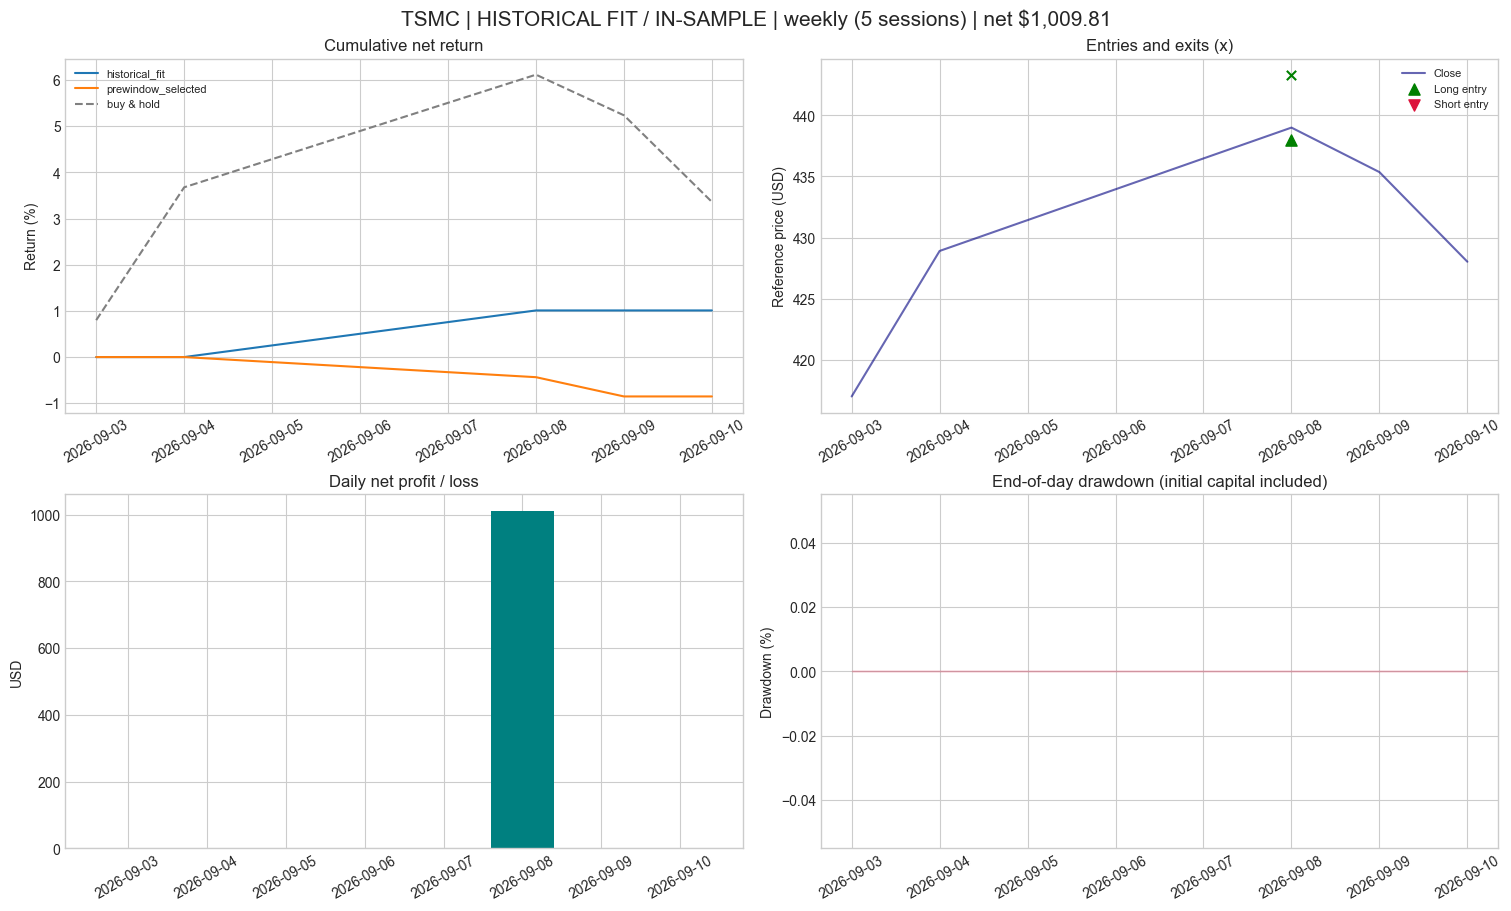

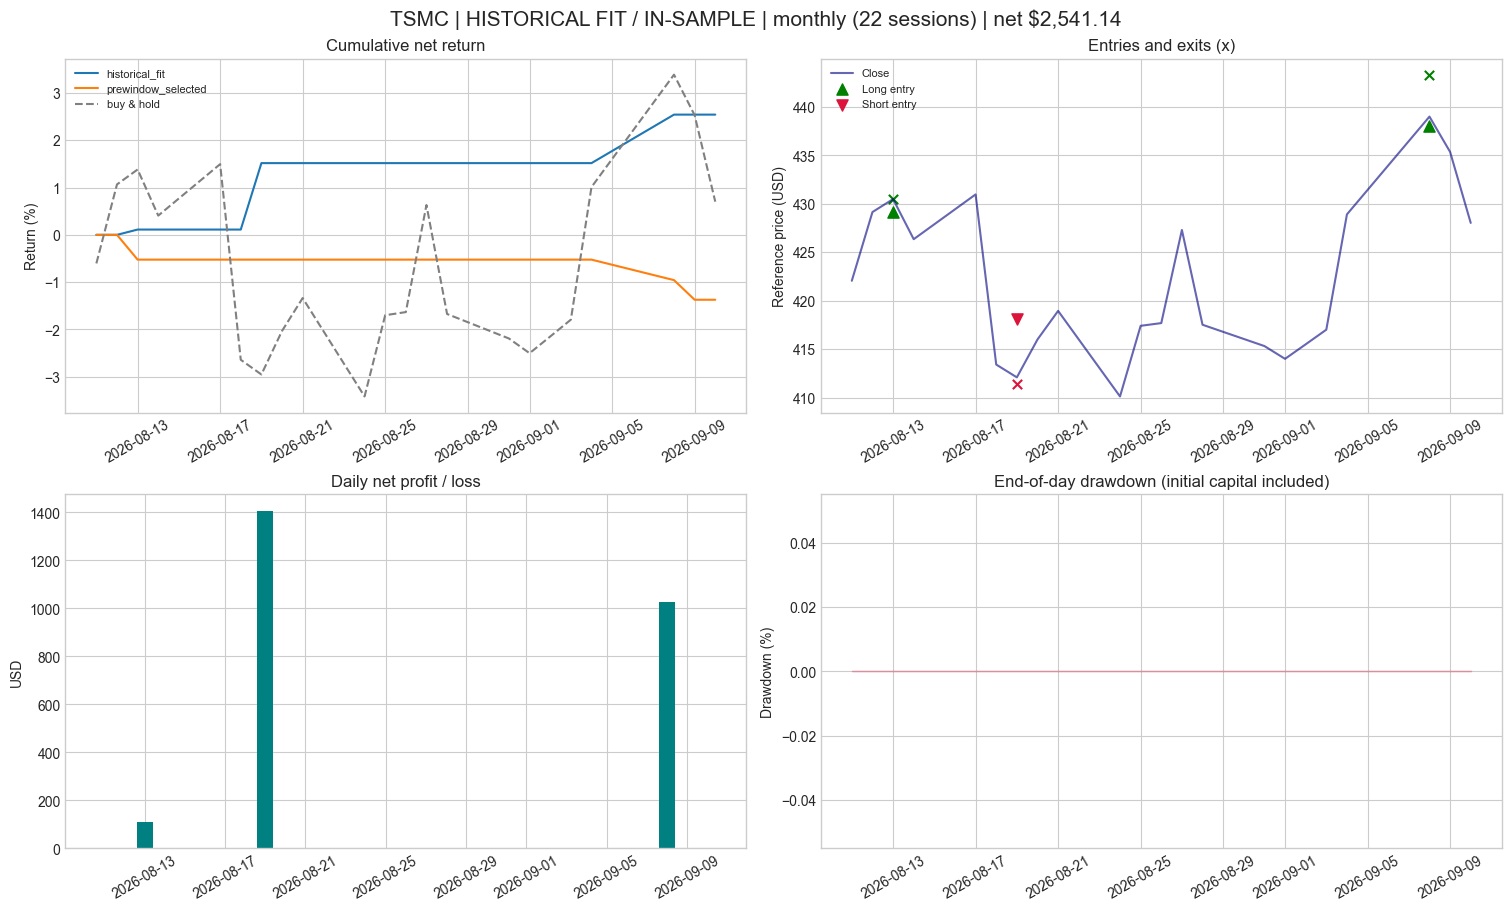

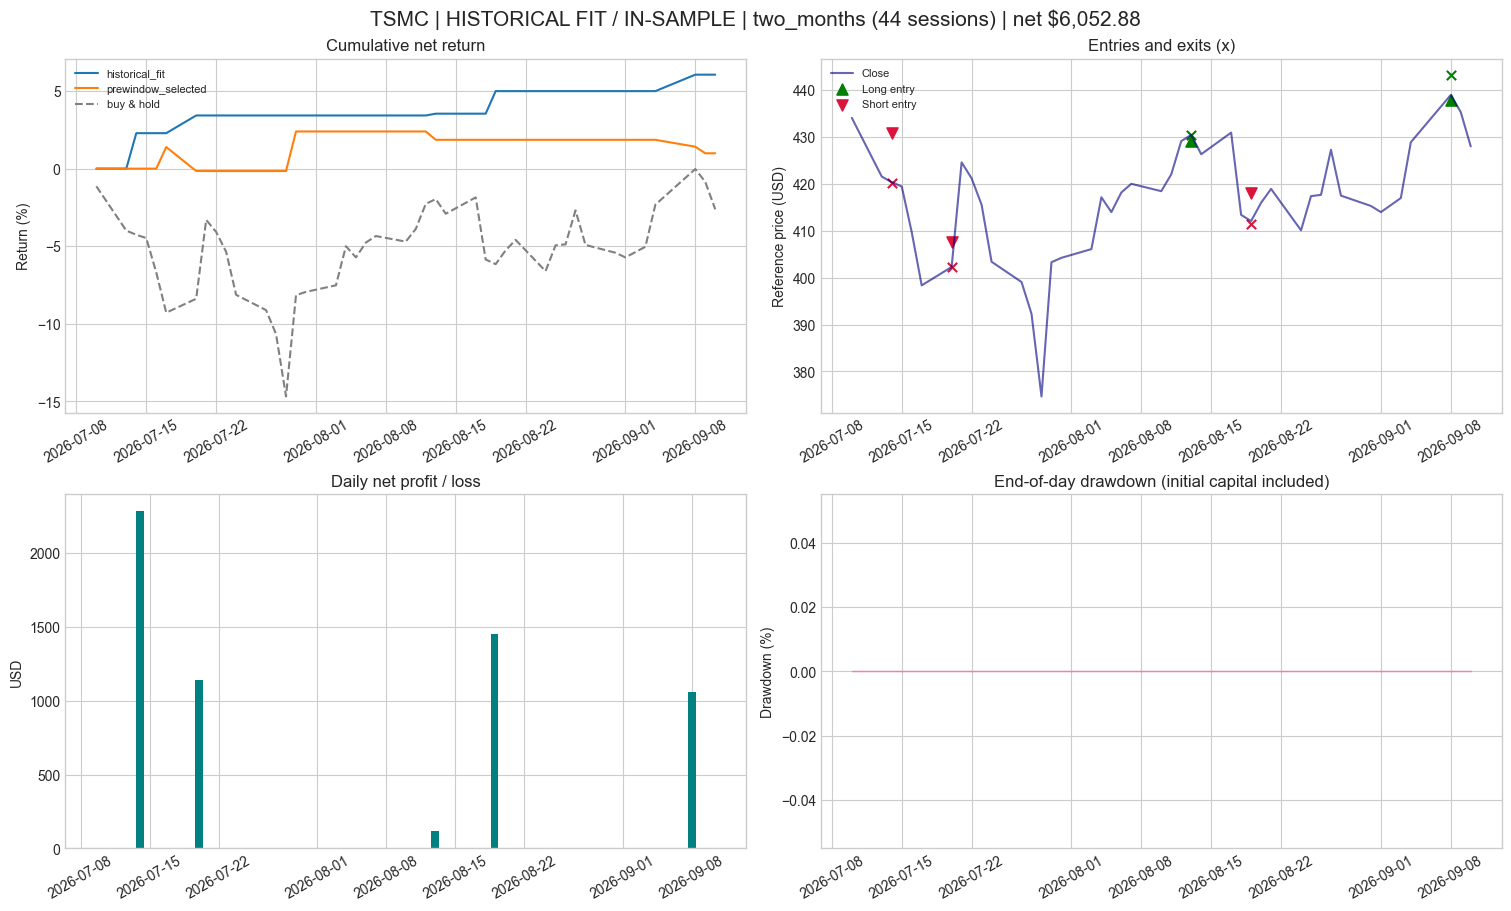

In [19]:
for window,count in WINDOWS.items():
    curve=results[(STRATEGY_MODE,window)]
    p=prices.tail(count)
    fig,axes=plt.subplots(2,2,figsize=(15,9),constrained_layout=True)
    label="HISTORICAL FIT / IN-SAMPLE" if STRATEGY_MODE=="historical_fit" else "PREWINDOW SELECTED"
    fig.suptitle(f"TSMC | {label} | {window} ({count} sessions) | net ${curve.Net_PnL.sum():,.2f}",fontsize=15)
    for mode in choices:
        c=results[(mode,window)]
        axes[0,0].plot(c.Date,100*(c.Equity/INITIAL_CAPITAL-1),label=mode)
    bh=p.Close.to_numpy()/p.Open.iloc[0]/(1+COST_BPS/10000)
    bh[-1]*=1-COST_BPS/10000
    axes[0,0].plot(curve.Date,100*(bh-1),label="buy & hold",color="gray",ls="--")
    axes[0,0].set(title="Cumulative net return",ylabel="Return (%)")
    axes[0,0].legend(fontsize=8)
    axes[0,1].plot(curve.Date,curve.Close,label="Close",color="navy",alpha=.6)
    for direction,color,marker,label in [(1,"green","^","Long entry"),(-1,"crimson","v","Short entry")]:
        t=curve[curve.Direction==direction]
        axes[0,1].scatter(t.Date,t.Open,color=color,marker=marker,s=65,label=label)
        axes[0,1].scatter(t.Date,t.Exit,color=color,marker="x",s=45)
    axes[0,1].set(title="Entries and exits (x)",ylabel="Reference price (USD)")
    axes[0,1].legend(fontsize=8)
    axes[1,0].bar(curve.Date,curve.Net_PnL,color=np.where(curve.Net_PnL>=0,"teal","coral"))
    axes[1,0].set(title="Daily net profit / loss",ylabel="USD")
    axes[1,1].fill_between(curve.Date,100*curve.Drawdown,0,color="crimson",alpha=.3)
    axes[1,1].set(title="End-of-day drawdown (initial capital included)",ylabel="Drawdown (%)")
    for ax in axes.flat: ax.tick_params(axis="x",rotation=30)
    fig.savefig(OUTPUT_DIR/f"{STRATEGY_MODE}_{window}_dashboard.png",dpi=150)
    plt.show()


## Selection bias, cost sensitivity and shorting restrictions

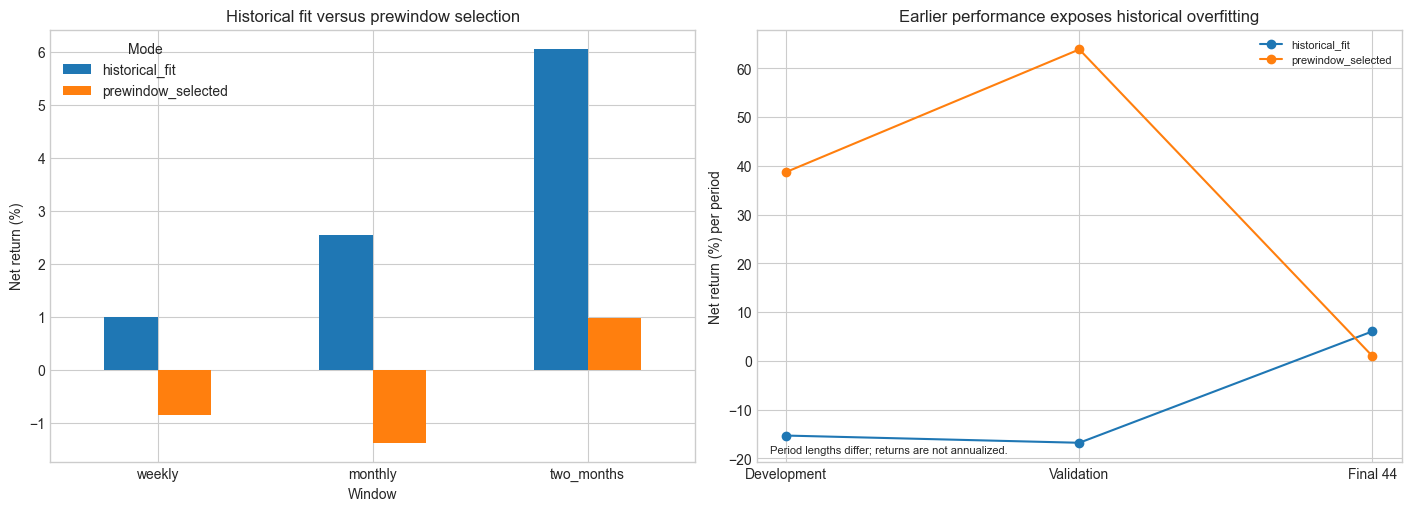

Window,monthly,two_months,weekly
Cost_bps,,,
0,3.155,7.107,1.212
5,2.848,6.579,1.111
10,2.541,6.053,1.010
20,1.931,5.009,0.808
40,0.722,2.952,0.406


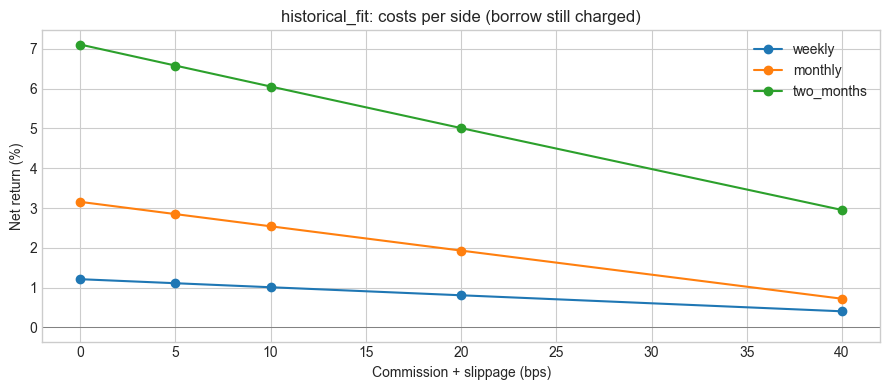

,Mode,Window,Long_only_return_pct
0,historical_fit,weekly,1.010
1,historical_fit,monthly,1.123
2,historical_fit,two_months,1.123
3,prewindow_selected,weekly,0.000
4,prewindow_selected,monthly,0.000
5,prewindow_selected,two_months,2.393


In [20]:
fig,axes=plt.subplots(1,2,figsize=(14,5),constrained_layout=True)
summary.pivot(index="Window",columns="Mode",values="Return_pct").reindex(WINDOWS).plot.bar(ax=axes[0],rot=0)
axes[0].set(title="Historical fit versus prewindow selection",ylabel="Net return (%)")
for mode,candidate_id in choices.items():
    row=candidates.loc[candidate_id]
    axes[1].plot(["Development","Validation","Final 44"],[row.Development_pct,row.Validation_pct,row.two_months_pct],marker="o",label=mode)
axes[1].set(title="Earlier performance exposes historical overfitting",ylabel="Net return (%) per period")
axes[1].legend(fontsize=8)
axes[1].text(.02,.02,"Period lengths differ; returns are not annualized.",transform=axes[1].transAxes,fontsize=8)
fig.savefig(OUTPUT_DIR/"selection_bias_comparison.png",dpi=150)
plt.show()
stress=[]
for mode,candidate_id in choices.items():
    for window,count in WINDOWS.items():
        for bps in [0,5,10,20,40]:
            curve=report_curve(prices,prior_atr,candidate_signals,candidates.loc[candidate_id],count,bps)
            stress.append(dict(Mode=mode,Window=window,Cost_bps=bps,Return_pct=100*(curve.Equity.iloc[-1]/INITIAL_CAPITAL-1)))
stress=pd.DataFrame(stress)
display(stress[stress.Mode==STRATEGY_MODE].pivot(index="Cost_bps",columns="Window",values="Return_pct").round(3))
fig,ax=plt.subplots(figsize=(9,4))
for window,g in stress[stress.Mode==STRATEGY_MODE].groupby("Window",sort=False):
    ax.plot(g.Cost_bps,g.Return_pct,marker="o",label=window)
ax.axhline(0,color="gray",lw=.7)
ax.set(title=f"{STRATEGY_MODE}: costs per side (borrow still charged)",xlabel="Commission + slippage (bps)",ylabel="Net return (%)")
ax.legend(); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"cost_sensitivity.png",dpi=150); plt.show()
# Disable short trades without reselecting the candidate: isolate reliance on shorting.
no_shorts={name:np.maximum(s,0) for name,s in candidate_signals.items()}
restriction=[]
for mode,candidate_id in choices.items():
    for window,count in WINDOWS.items():
        curve=report_curve(prices,prior_atr,no_shorts,candidates.loc[candidate_id],count,COST_BPS)
        restriction.append(dict(Mode=mode,Window=window,Long_only_return_pct=100*(curve.Equity.iloc[-1]/INITIAL_CAPITAL-1)))
restriction=pd.DataFrame(restriction)
display(restriction.round(3))


## Export results and explain the primary rule

In [21]:
candidates.to_csv(OUTPUT_DIR/"candidate_research.csv",index_label="Candidate_ID")
summary.to_csv(OUTPUT_DIR/"window_summary.csv",index=False)
selection_table.to_csv(OUTPUT_DIR/"selected_strategies.csv",index_label="Candidate_ID")
stress.to_csv(OUTPUT_DIR/"cost_sensitivity.csv",index=False)
restriction.to_csv(OUTPUT_DIR/"shorting_restriction.csv",index=False)
audit.to_csv(OUTPUT_DIR/"forecast_parity_audit.csv",index=False)
fresh_forecasts.to_csv(OUTPUT_DIR/"fresh_forecasts.csv",index=False)
for (mode,window),curve in results.items():
    curve.to_csv(OUTPUT_DIR/f"{mode}_{window}_equity.csv",index=False)
    curve[curve.Direction!=0].to_csv(OUTPUT_DIR/f"{mode}_{window}_trades.csv",index=False)
config=dict(dataset=DATASET,paths=PATHS,windows=WINDOWS,main_window=MAIN_WINDOW,strategy_mode=STRATEGY_MODE,
    initial_capital=INITIAL_CAPITAL,commission_bps=COMMISSION_BPS,slippage_bps=SLIPPAGE_BPS,
    borrow_annual=BORROW_ANNUAL,choices=choices,candidates=len(candidates),
    selection_cutoff=str(prices.Date.iloc[selection_end-1].date()),
    historical_objective="max monthly net return subject to positive returns in all three windows, when feasible",
    warning="Historical fit uses evaluation outcomes; this is not evidence of future profitability.")
(OUTPUT_DIR/"configuration.json").write_text(json.dumps(config,indent=2))
row=candidates.loc[choices[STRATEGY_MODE]]
print("MODE:",STRATEGY_MODE)
print("SIGNAL:",row.Signal,"| STOP ATR:",row.Stop_ATR,"| TAKE ATR:",row.Take_ATR)
print("Main-window trades (all costs included):")
display(results[(STRATEGY_MODE,MAIN_WINDOW)].query("Direction != 0").round(3))
print("Historical-fit returns are optimized on these same windows. The earlier-selected strategy is the separate comparison.")
print("Saved charts, full candidate table, equity curves and trade logs:",OUTPUT_DIR)


MODE: historical_fit
SIGNAL: z_breakout_5_1.5__long_short | STOP ATR: 0.5 | TAKE ATR: 0.5
Main-window trades (all costs included):


,Date,Direction,Return,Equity,Drawdown,Open,Close,Exit,Reason,Trading_cost,Borrow_cost,Notional,Ambiguous,Shares,Gross_PnL,Net_PnL
2,2026-08-13,1.0,0.001,100111.820,0.0,429.15,430.49,430.490,close,200.112,0.000,99900.100,False,232.786,311.932,111.820
6,2026-08-19,-1.0,0.014,101516.026,0.0,418.13,412.09,411.380,target,198.409,11.906,100011.808,False,-239.188,1614.521,1404.206
19,2026-09-08,1.0,0.010,102541.141,0.0,438.02,439.00,443.329,target,204.058,0.000,101414.611,False,231.530,1229.174,1025.116


Historical-fit returns are optimized on these same windows. The earlier-selected strategy is the separate comparison.
Saved charts, full candidate table, equity curves and trade logs: F:\SEM-7\Time Series Analysis\Project\Trading\short_horizon_outputs_v2
